### Уравнения Навье–Стокса (несжимаемая жидкость)

$$
\rho \left( \frac{\partial \mathbf{v}}{\partial t} + (\mathbf{v} \cdot \nabla) \mathbf{v} \right) = -\nabla p + \mu \nabla^2 \mathbf{v} + \rho \mathbf{g}
$$

$$
\nabla \cdot \mathbf{v} = 0
$$

**Начальное условие:** $\mathbf{v}(\mathbf{x}, 0) = \mathbf{v}_0(\mathbf{x})$

**Граничное условие:** $\mathbf{v}\big|_{\partial \Omega} = \mathbf{v}_{wall}$

---

| Символ | Описание | Тип |
| :--- | :--- | :--- |
| $\mathbf{v}$ | вектор скорости | **переменная** |
| $p$ | давление | **переменная** |
| $\rho$ | плотность | константа |
| $\mu$ | динамическая вязкость | константа |
| $\mathbf{g}$ | ускорение массовых сил | константа |
| $\mathbf{v}_0$ | начальное поле скорости | константа |
| $\mathbf{v}_{wall}$ | скорость на границе | константа |

# Визуализация

In [ ]:
from navier_stokes_tree import build_navier_stokes_2d
from visualise_ns_tree import main as visualize

In [ ]:
visualize()

Сохранено: /content/outputs/navier_stokes_tree_graph.png
Сохранено: /content/outputs/navier_stokes_adjacency.png


Посмотрим, что у нас получилось

## Граф зависимостей

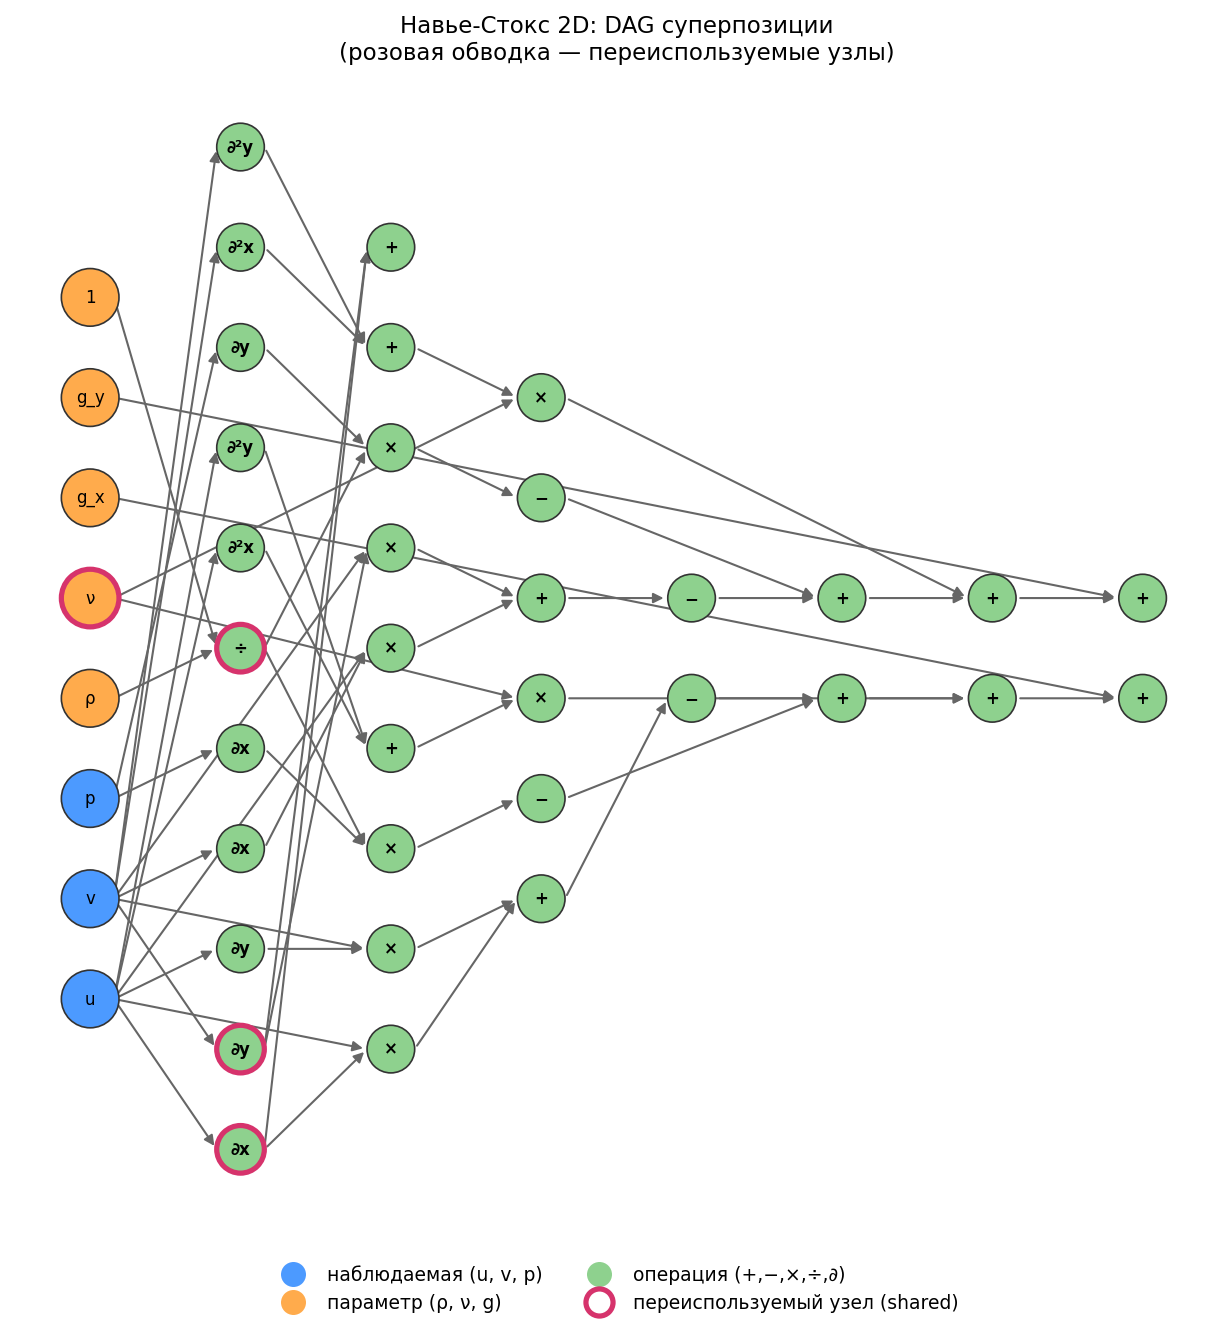

## Матрица причинной смежности

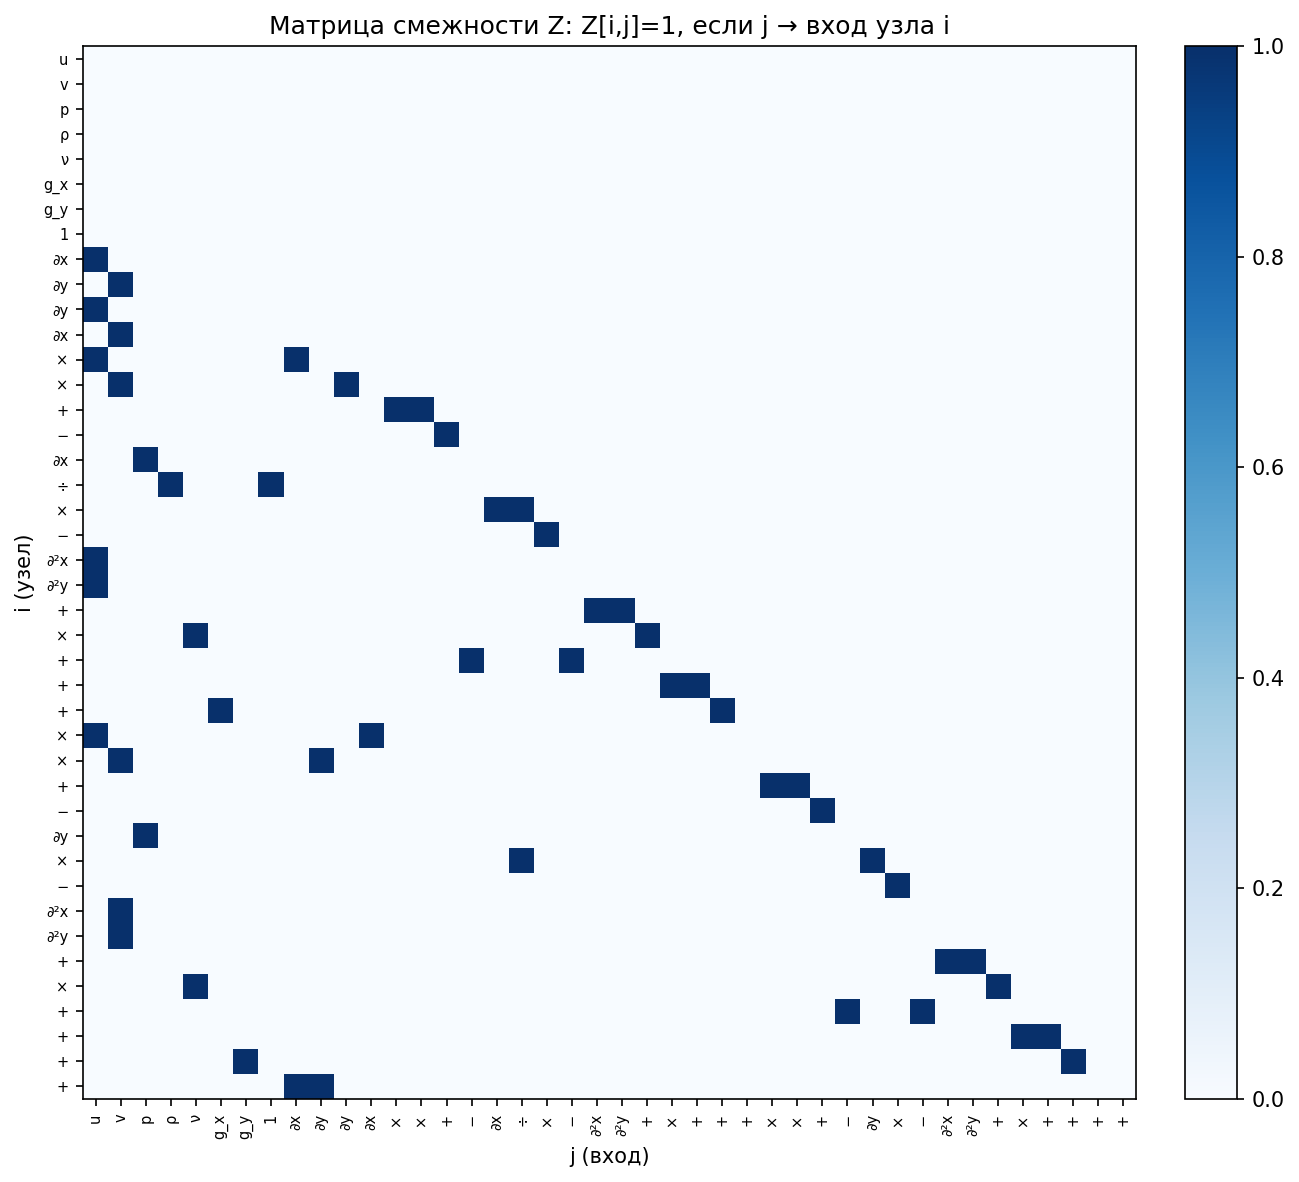

## Загрузим датку и сравним методы решения прямой задачи

In [ ]:
!pip install -q h5py requests scipy

In [ ]:
from data_PDEload import load_pdebench_2d_ns, load_taylor_green, load_kolmogorov


data = load_pdebench_2d_ns(
    file_index=0,
    trajectory_index=0,
    n_observations=300,
    noise_level=0.02,
)


print(f"Источник: {data['params']['source']}")
print(f"Сетка: {data['grid']['n_points']}×{data['grid']['n_points']}")
print(f"Времени: {data['grid']['n_time']}, ν = {data['params']['nu']:.5f}")

[cache hit] /root/.cache/navier_stokes_data/133280 (9906.4 MB)
Чтение /root/.cache/navier_stokes_data/133280 (lazy loading) ...
Найден velocity: shape=(4, 1000, 512, 512, 2)
Загружено: u.shape = (100, 128, 128), dtype=float32
  t_raw: shape=(1000,), dtype=float32, first=0.0, last=4.994999885559082
Источник: PDEBench (file 0, traj 0)
Сетка: 128×128
Времени: 100, ν = 0.00100


In [ ]:
!pip install torchdiffeq

In [ ]:
!pip install torch

In [ ]:
from all_solvers import solve_fd, solve_scipy, solve_torch, compare_solutions


x, y, t = data["x"], data["y"], data["t"]
omega0 = data["omega0"]
nu = data["params"]["nu"]


sol_fd = solve_fd(x, y, t, omega0, nu)
sol_sp = solve_scipy(x, y, t, omega0, nu)
sol_torch = solve_torch(x, y, t, omega0, nu)

truth = {"u": data["u"], "v": data["v"], "omega": data["omega"]}

compare_solutions(
    x, y, t,
    observations=data["observations"],
    truth=truth,
    sol_fd=sol_fd,
    sol_sp=sol_sp,
    sol_torch=sol_torch,
    output_path="outputs/ns2d_comparison.png",
)

Сохранено: outputs/ns2d_comparison.png


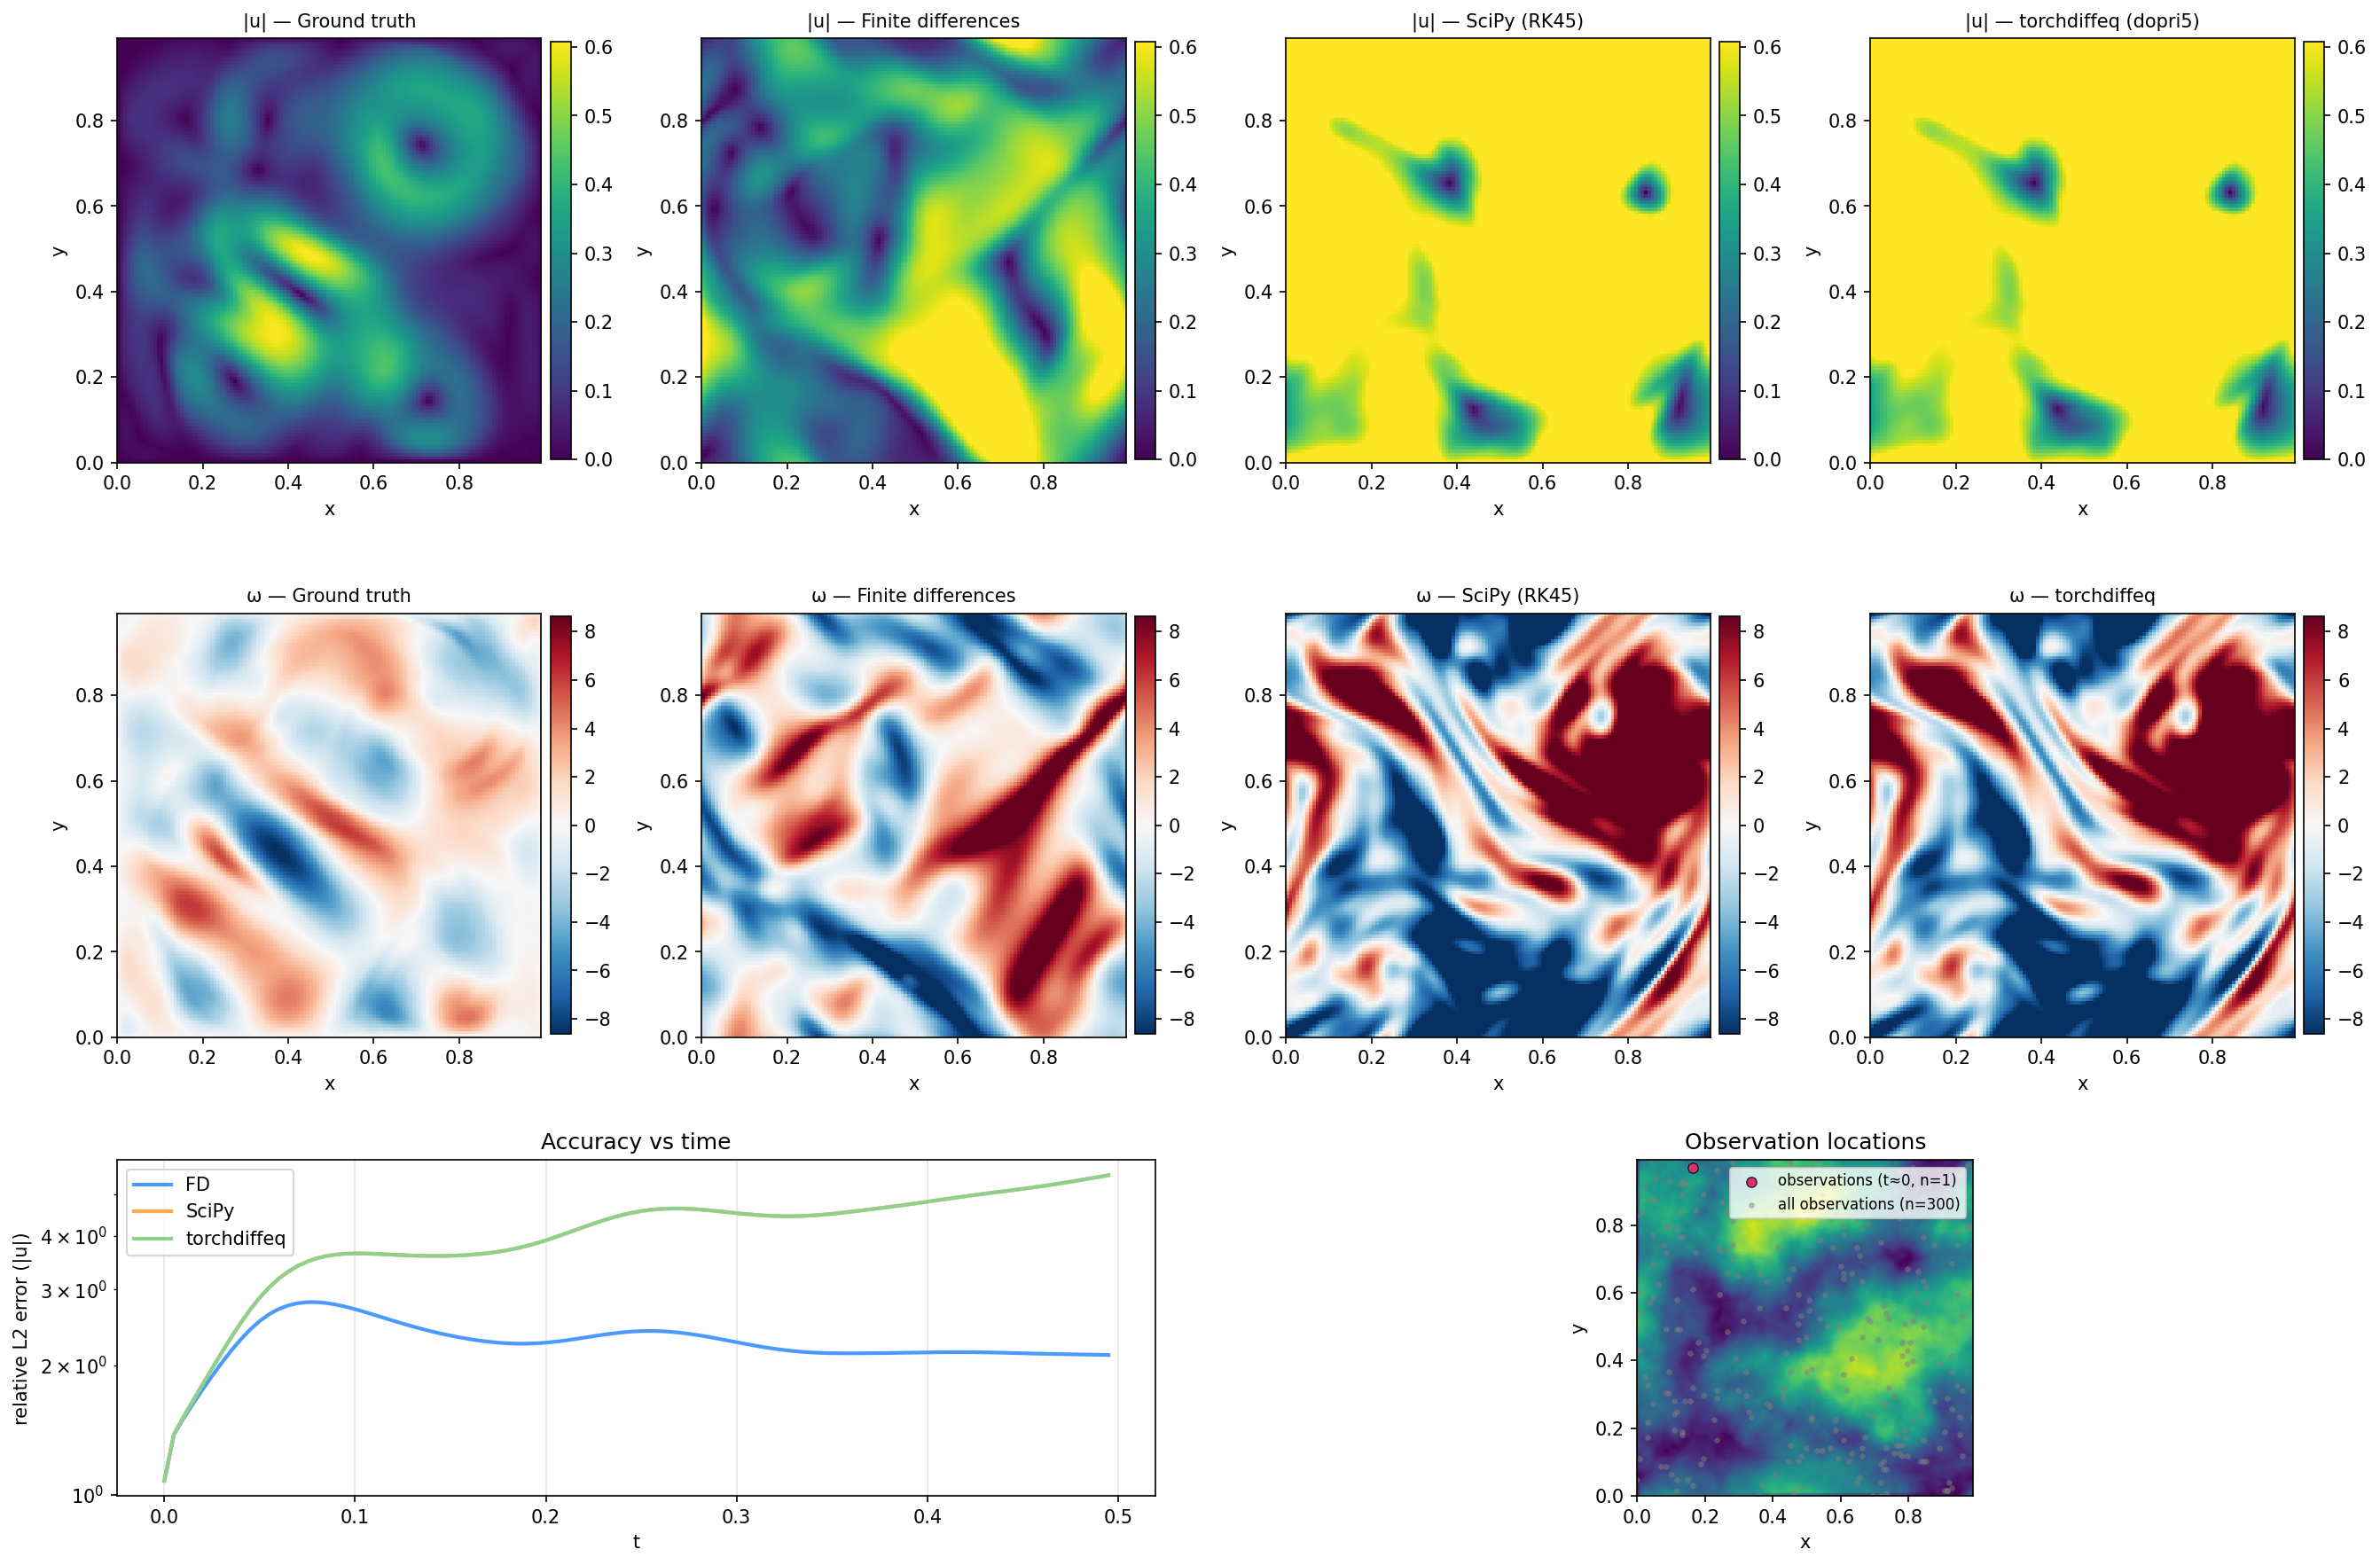